Welcome to this notebook. <br>
1) In this notebook your assignment is to predict the type of dog with a Neural Network.<br>
Written by Bart Bozon, please copy & use as you would like.

# Loading the data #

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/generated_dogs.csv'
try:
    df = pd.read_csv(url)
    print("Data loaded successfully!")
    print(f"Shape: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")

# Display first rows
df.head()

Data loaded successfully!
Shape: (10000, 7)


,Breed,Gender,Age_time_of_death,Height,Weight,Likes,Skills
0,Border Collie,Male,13.3,20.70,40.50,likes_people_better_than_dogs,high_trainability
1,Basset Hound,Male,12.7,13.65,51.02,likes_dogs_better_than_people,no_special_skills
2,Dachshund,Female,14.0,8.59,24.58,likes_dogs_better_than_people,barks_like_hell
3,Boston Terrier,Male,12.3,16.27,20.13,likes_people_better_than_dogs,no_special_skills
4,Chihuahua,Male,15.3,7.14,5.92,likes_dogs_better_than_people,barks_like_hell


# 1. Exploratory Data Analysis (EDA)
Before we build the model, we need to understand the data. We will check for missing values, analyze distributions, and look at correlations.

In [2]:
# Check for missing values and data types
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Breed              10000 non-null  object 
 1   Gender             10000 non-null  object 
 2   Age_time_of_death  10000 non-null  float64
 3   Height             10000 non-null  float64
 4   Weight             10000 non-null  float64
 5   Likes              10000 non-null  object 
 6   Skills             10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB

--- Missing Values ---
Breed                0
Gender               0
Age_time_of_death    0
Height               0
Weight               0
Likes                0
Skills               0
dtype: int64


/tmp/ipykernel_189045/3282785823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=breed_counts.index, y=breed_counts.values, palette='viridis')


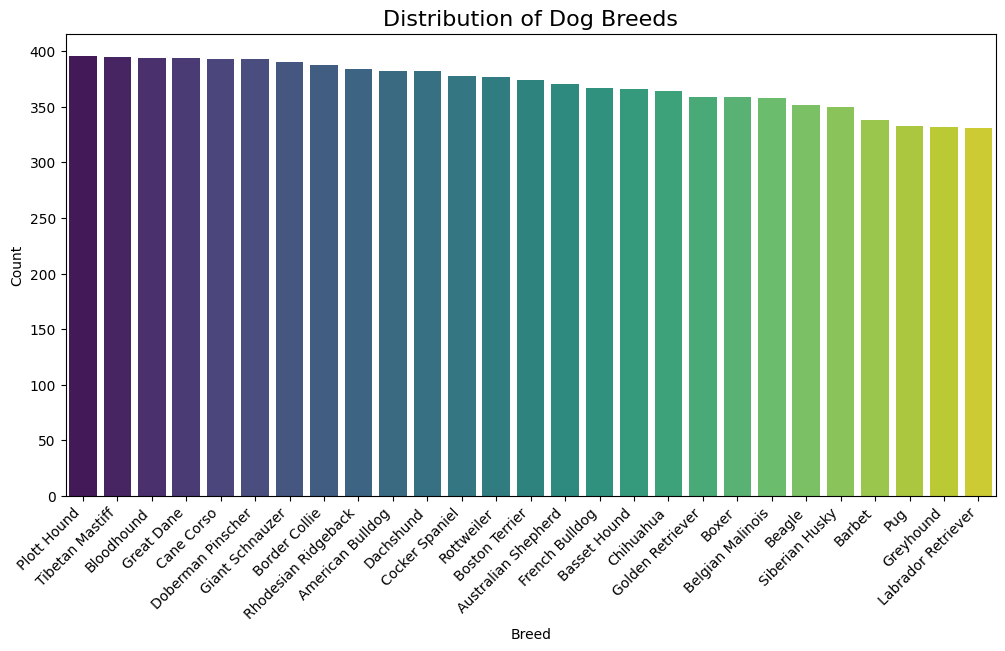

Number of unique breeds: 27


In [3]:
# Visualize the Target Distribution (Breed)
plt.figure(figsize=(12, 6))
breed_counts = df['Breed'].value_counts()
sns.barplot(x=breed_counts.index, y=breed_counts.values, palette='viridis')
plt.title('Distribution of Dog Breeds', fontsize=16)
plt.xlabel('Breed')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

print(f"Number of unique breeds: {df['Breed'].nunique()}")

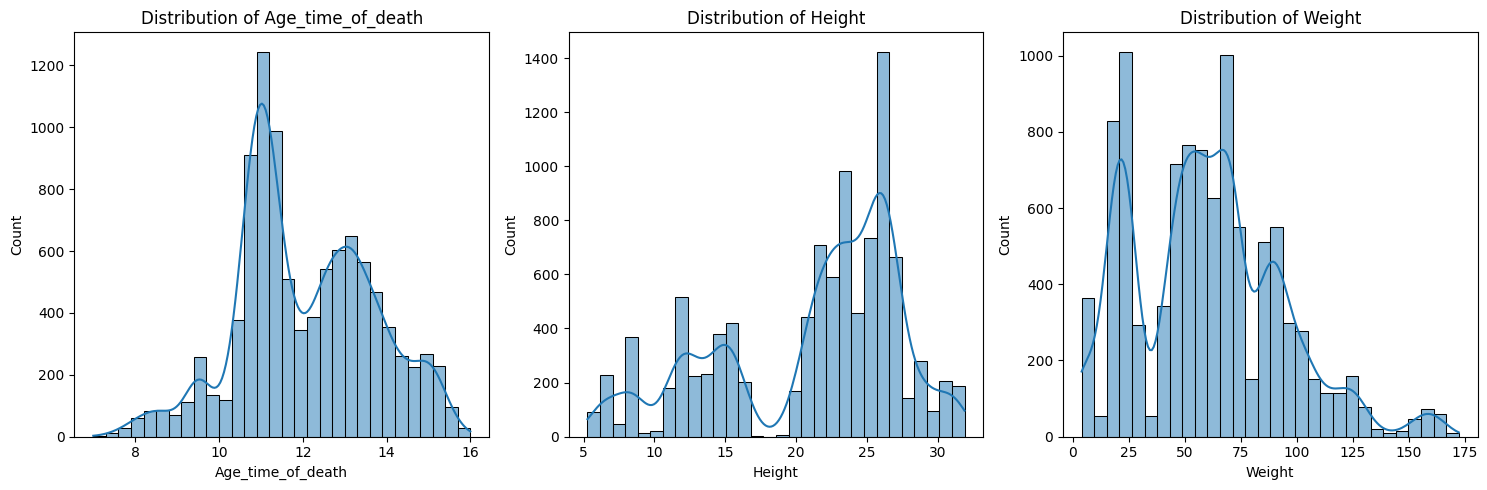

In [4]:
# Visualize Numerical Features Distributions
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

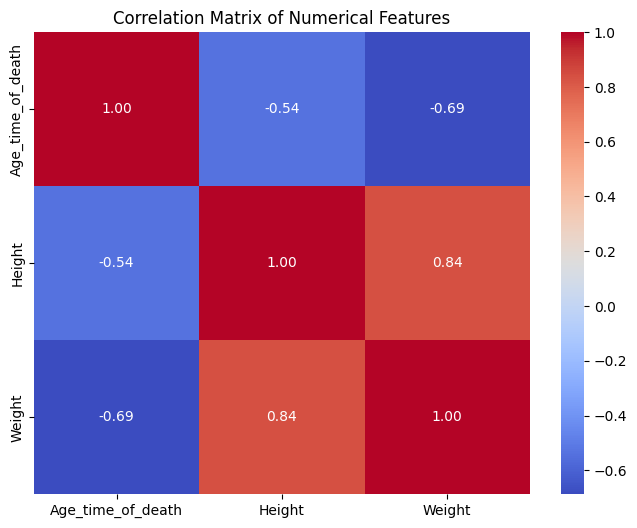

In [5]:
# Correlation Matrix (Numerical Features)
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 2. Import Custom Evaluator Class
We will use the `ClassificationEvaluator` class to train and compare our models, including the Neural Network.

In [6]:
import os
import sys

# Add the directory containing ModelEvaluator.py to sys.path
current_dir = os.getcwd()
path_to_add = os.path.abspath(os.path.join(current_dir, '../Week_02/Classification'))

if path_to_add not in sys.path:
    sys.path.append(path_to_add)
    print(f"Added path: {path_to_add}")

# Import the class
try:
    from ModelEvaluator import ClassificationEvaluator
    print("✅ ClassificationEvaluator imported successfully!")
except ImportError as e:
    print(f"❌ Error importing ClassificationEvaluator: {e}")
    print("Please ensure the file 'ModelEvaluator.py' exists in the specified path and contains the 'ClassificationEvaluator' class.")

Added path: /home/robin/Data science code/Homework/Week_02/Classification


2025-12-10 18:07:01.624233: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 18:07:01.679205: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ ClassificationEvaluator imported successfully!


2025-12-10 18:07:02.888804: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# 3. Data Exploration with PCA
Before training, let's use PCA to see if the classes are separable and decide which features might be redundant.


🔍 STARTING PCA EXPLORATION: DATA EXPLORATION
   -> Dropped columns: ['Breed']
   -> Applying Preprocessing...
   -> Fitting PCA (n_components=0.95)...


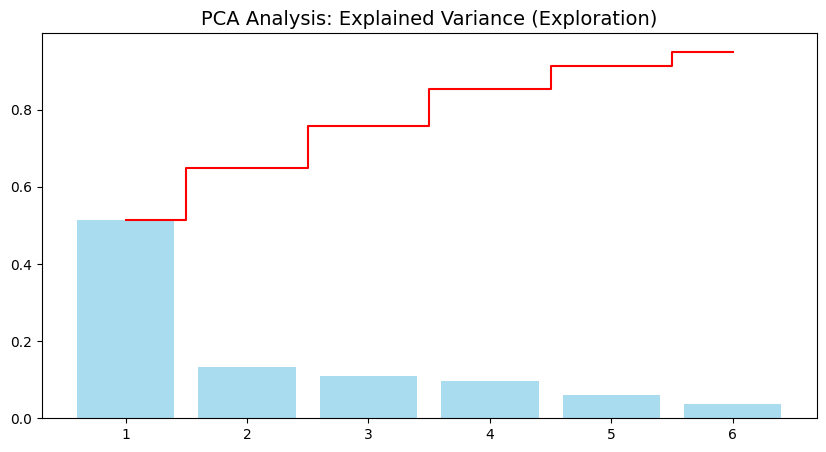

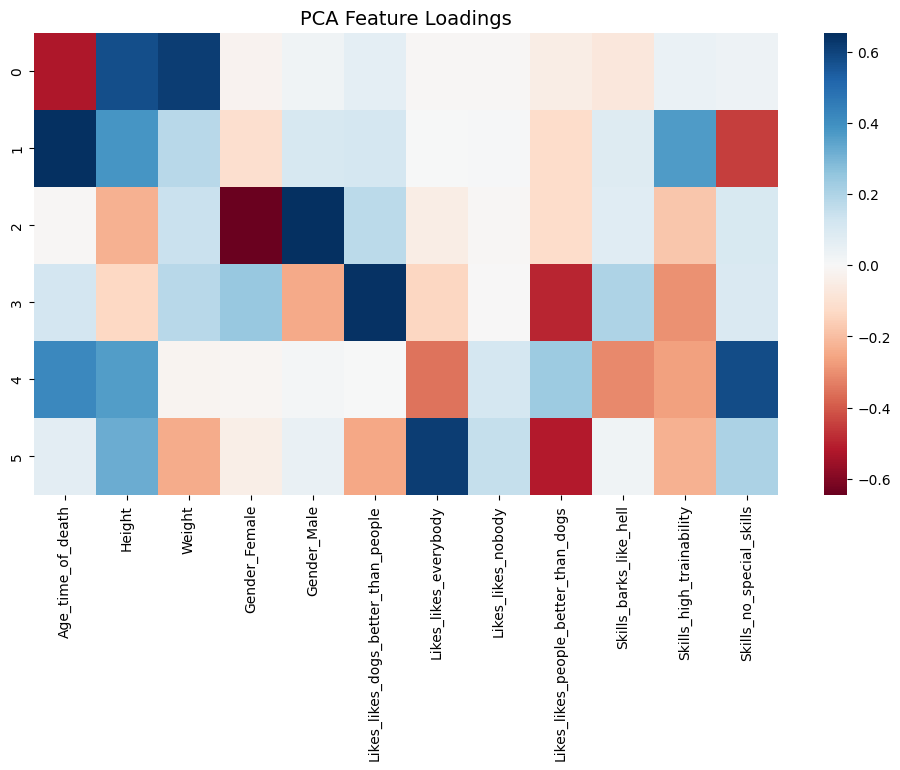

✅ PCA Exploration Completed.


In [7]:
# Initialize evaluator for exploration
explorer = ClassificationEvaluator(name="Data Exploration")

# Run PCA Analysis
# We drop 'Age_time_of_death' to see if Height/Weight/Gender are enough
explorer.explore_data_with_pca(
    df, 
    target_col='Breed', 
    cols_to_drop=[], # Keep all features for now
    n_components=0.95
)

# 4. Model Training (Neural Network)
Now we will train a Neural Network to predict the dog breed. We will compare a simple network with a deeper one.

In [8]:
# Initialize Evaluator
evaluator = ClassificationEvaluator(name="Dog Breed NN Analysis")

# --- Add Options ---
# Option 0: Standard (Scaling + Dummies)
evaluator.add_option(scaling=True, dummies=True)

# Option 1: PCA Reduced (Scaling + Dummies + PCA)
# This can help the NN train faster by removing noise
evaluator.add_option(scaling=True, dummies=True, pca=True, n_components=0.95)

# --- Add Neural Network Models ---

# Model 1: Simple NN (1 hidden layer)
evaluator.add_neural_network(
    name='Simple_NN',
    layers=[(32, 'relu')], # 1 Hidden layer with 32 neurons
    epochs=50,
    batch_size=16,
    patience = 5
)

# Model 2: Deep NN (2 hidden layers)
evaluator.add_neural_network(
    name='Deep_NN',
    layers=[(64, 'relu'), (32, 'relu')], # 2 Hidden layers
    epochs=50,
    batch_size=16,
    patience = 5
)

# --- Add a Baseline Model (Random Forest) ---
from sklearn.ensemble import RandomForestClassifier
evaluator.add_model(
    name='RandomForest',
    model=RandomForestClassifier(random_state=42),
    params={'n_estimators': [100]}
)

# --- Run Experiments ---
# We optimize for Accuracy since classes are somewhat balanced (based on EDA)
evaluator.run_experiments(
    df, 
    target_col='Breed', 
    scoring=['accuracy', 'f1_macro'], 
    refit='accuracy'
)


🚀 START EXPERIMENT: DOG BREED NN ANALYSIS
📊 Target Column: 'Breed'
ℹ️  Target is categorical. Encoding with LabelEncoder.

--- ⚙️ Processing Opt0_S1_D1 ---
   🧠 Training Neural Network: Simple_NN...


I0000 00:00:1765386423.827411  189045 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9692 MB memory:  -> device: 0, name: NVIDIA RTX A3000 12GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-12-10 18:07:05.099880: I external/local_xla/xla/service/service.cc:163] XLA service 0x70ad8c004c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-10 18:07:05.099908: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A3000 12GB Laptop GPU, Compute Capability 8.6
2025-12-10 18:07:05.112030: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-10 18:07:05.176034: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
I0000 00:00:1765386425.959927  189182 device_compiler.h:196] Compiled cluster using XLA!  This lin

   ✅ Simple_NN: accuracy=0.9630 (Stopped at epoch 50)
   🧠 Training Neural Network: Deep_NN...
   ✅ Deep_NN: accuracy=0.9595 (Stopped at epoch 29)
   ✅ RandomForest: accuracy=0.9696

--- ⚙️ Processing Opt1_S1_D1_PCA ---
   🧠 Training Neural Network: Simple_NN...
   ✅ Simple_NN: accuracy=0.9605 (Stopped at epoch 50)
   🧠 Training Neural Network: Deep_NN...
   ✅ Deep_NN: accuracy=0.9550 (Stopped at epoch 35)
   ✅ RandomForest: accuracy=0.9617

🏁 Experiments for Dog Breed NN Analysis completed!


# 5. Results & Visualization
Let's analyze the performance of our models.


=== [Dog Breed NN Analysis] Top 10 Results (Sorted by accuracy) ===
       Model                   Config Option_ID  accuracy  f1_macro                       params  n_estimators
RandomForest  Opt0 (Scale:Yes PCA:No)      Opt0    0.9696    0.9688                          NaN         100.0
   Simple_NN  Opt0 (Scale:Yes PCA:No)      Opt0    0.9630       NaN               [(32, 'relu')]           NaN
RandomForest Opt1 (Scale:Yes PCA:Yes)      Opt1    0.9618    0.9606                          NaN         100.0
   Simple_NN Opt1 (Scale:Yes PCA:Yes)      Opt1    0.9605       NaN               [(32, 'relu')]           NaN
     Deep_NN  Opt0 (Scale:Yes PCA:No)      Opt0    0.9595       NaN [(64, 'relu'), (32, 'relu')]           NaN
     Deep_NN Opt1 (Scale:Yes PCA:Yes)      Opt1    0.9550       NaN [(64, 'relu'), (32, 'relu')]           NaN


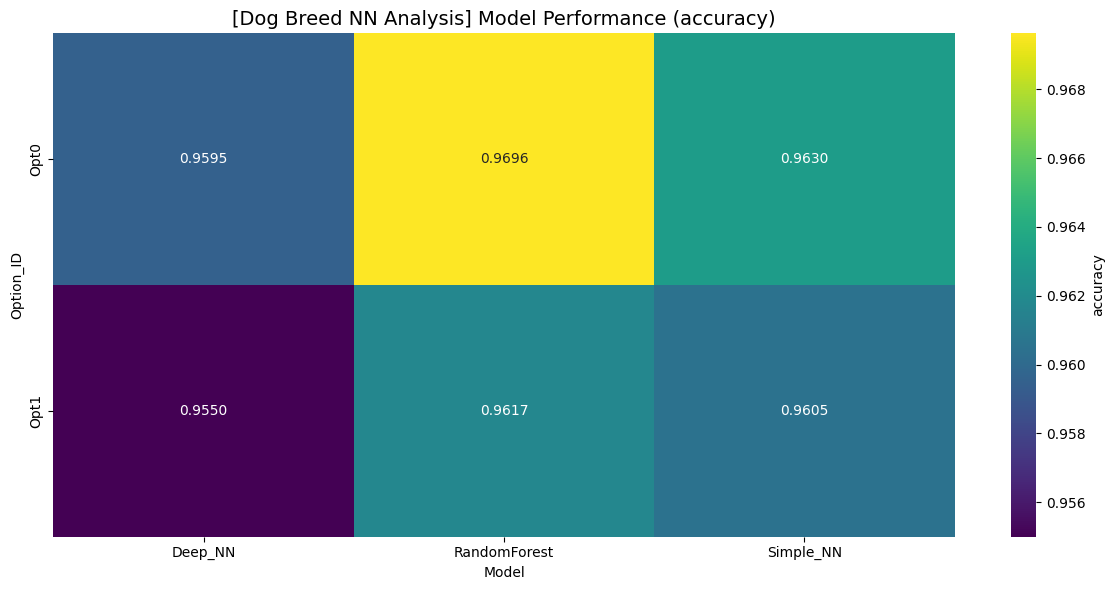

In [9]:
# Print Results Table
evaluator.print_results(sort_by='accuracy', top_n=10)

# Heatmap of Model Performance
evaluator.plot_heatmap(metric='accuracy')

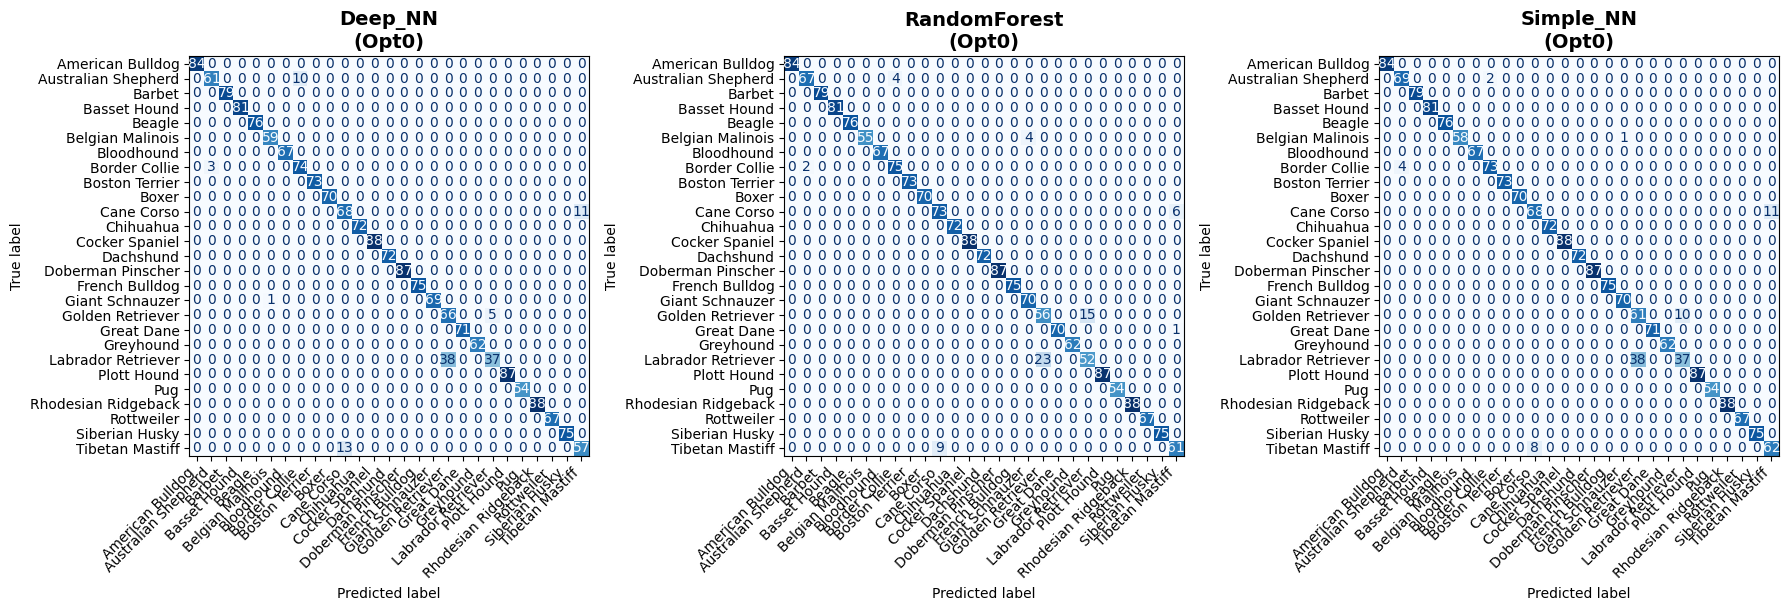

In [10]:
# Plot Confusion Matrix for the best model
# This shows us exactly which breeds are confused with each other
evaluator.plot_confusion_matrix(metric_for_selection='accuracy')

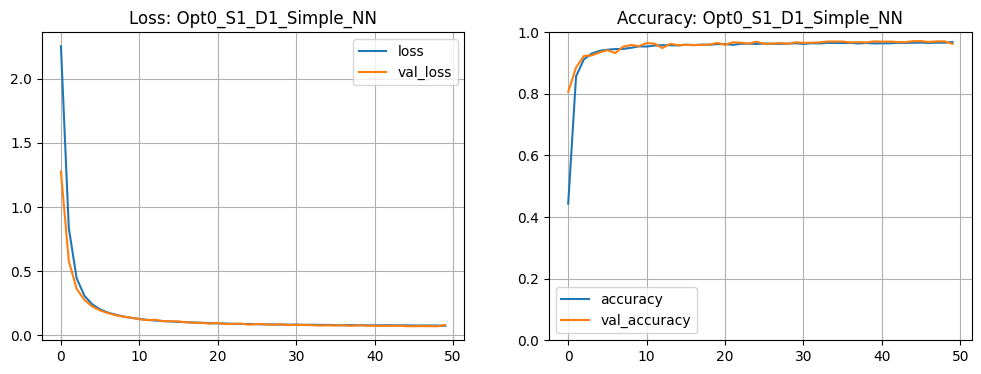

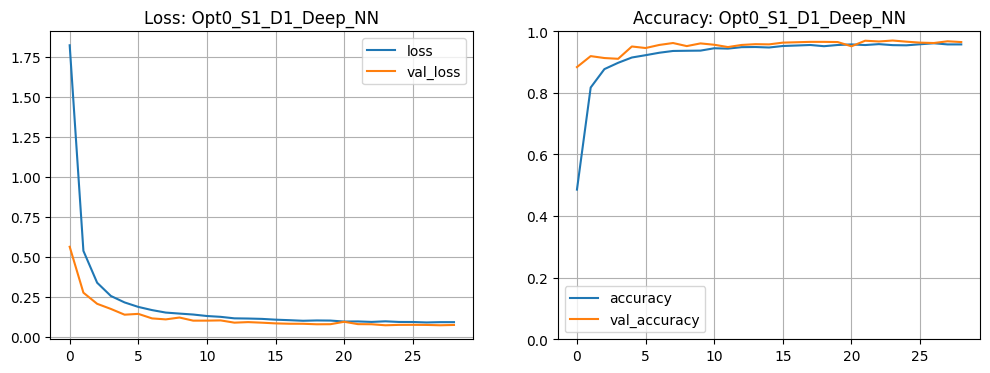

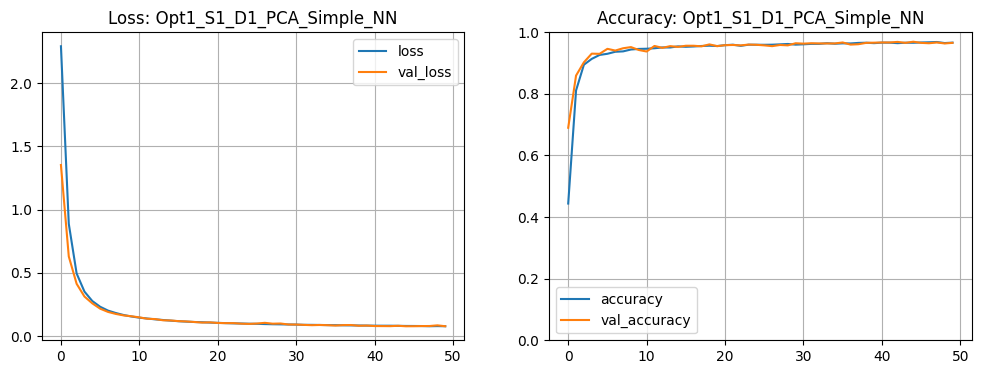

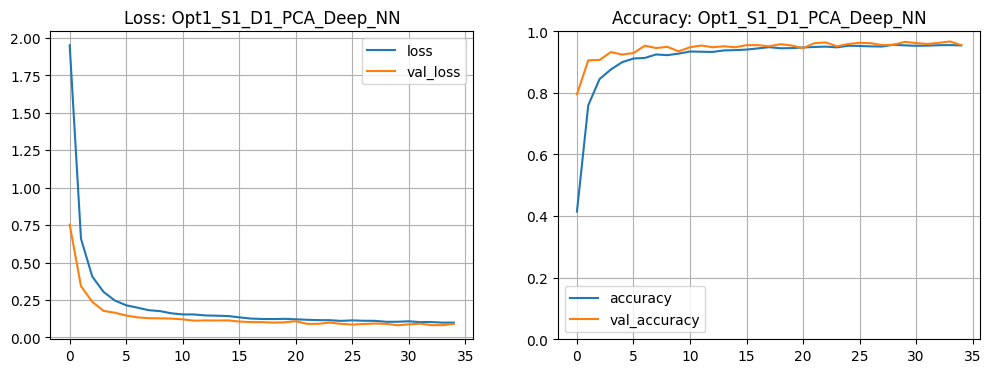

In [11]:
# Plot Learning Curves for Neural Networks
# Check for overfitting (if loss goes down but val_loss goes up)
evaluator.plot_learning_curve()